In [11]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
# Load the Iris dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [13]:
# Explore the dataset
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Null Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean   

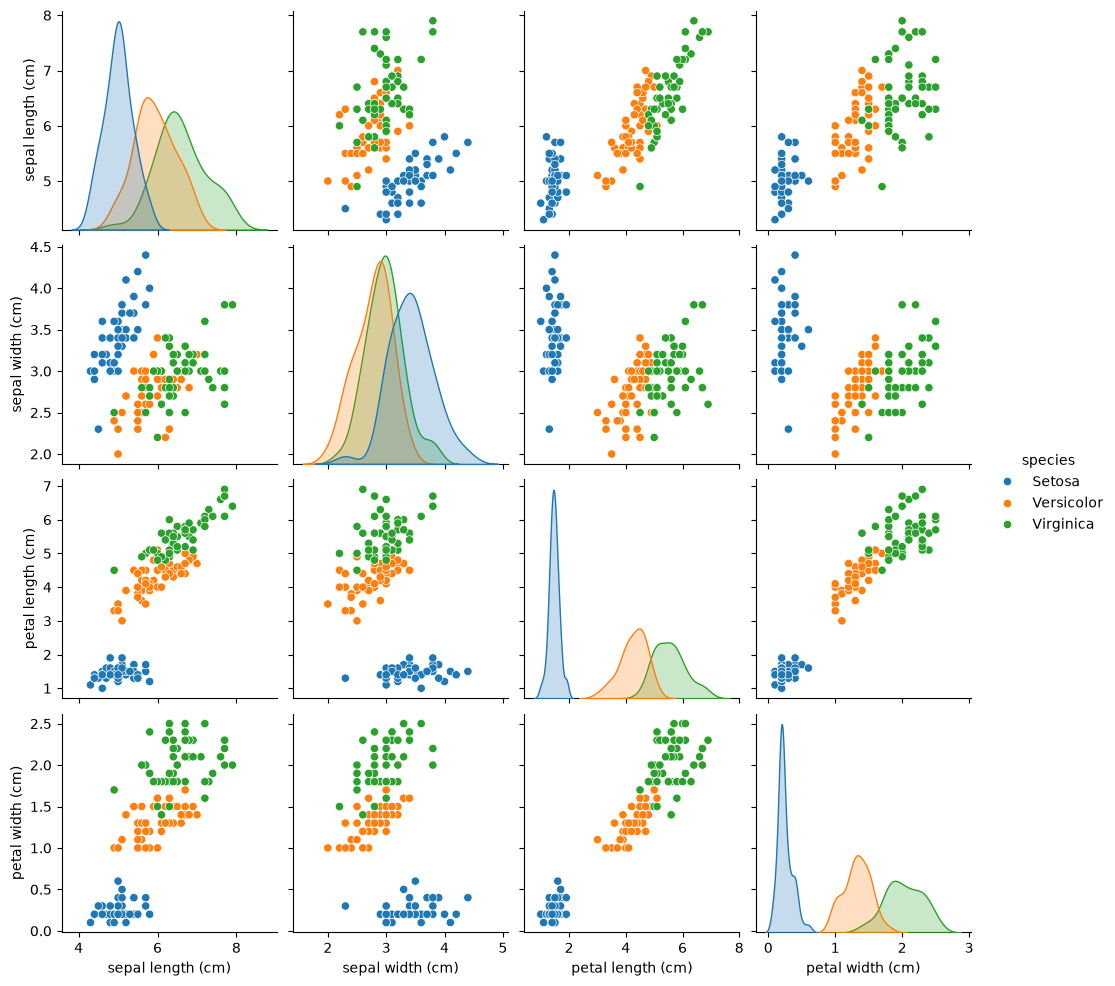

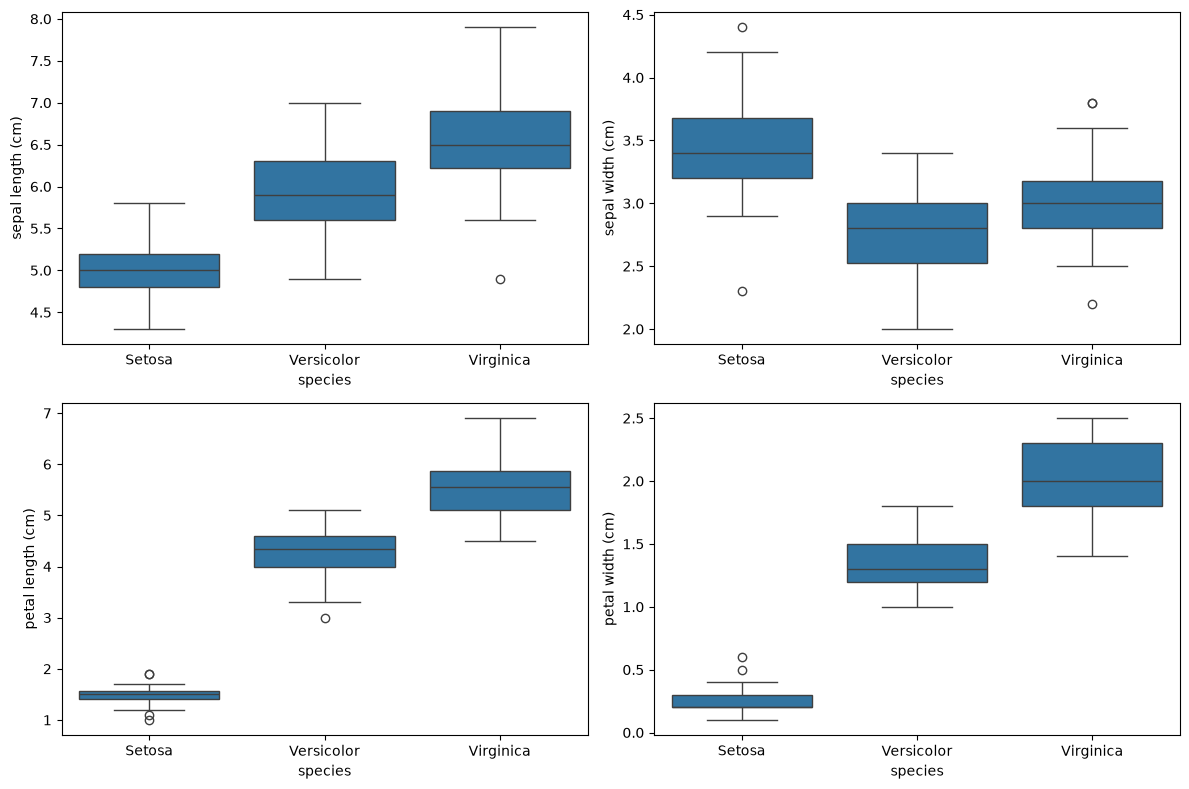

In [14]:
# Pairplot of all features
sns.pairplot(df, hue="species")
plt.show()

# Boxplots for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x="species", y="sepal length (cm)", ax=axes[0,0])
sns.boxplot(data=df, x="species", y="sepal width (cm)", ax=axes[0,1])
sns.boxplot(data=df, x="species", y="petal length (cm)", ax=axes[1,0])
sns.boxplot(data=df, x="species", y="petal width (cm)", ax=axes[1,1])

plt.tight_layout()
plt.show()

In [15]:
# Feature selection discussion
print("Petal length and petal width appear to be the most discriminative features.")
print("They show the clearest separation between the three iris species in the pairplots and boxplots.")

Petal length and petal width appear to be the most discriminative features.
They show the clearest separation between the three iris species in the pairplots and boxplots.


In [16]:
# Split the data into features and target
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Train two classification models
lr = LogisticRegression(max_iter=200)
knn = KNeighborsClassifier()

lr.fit(X_train, y_train)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Setosa','Versicolor','Virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [18]:
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
knn_pred = knn.predict(X_test)

print("KNN Accuracy:")
print(accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

KNN Accuracy:
1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
lr_accuracy = accuracy_score(y_test, lr_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)

if lr_accuracy > knn_accuracy:
    print("Best Model: Logistic Regression")
    print(f"Accuracy: {lr_accuracy:.3f}")
    print("It achieved the highest accuracy on the test set.")
elif knn_accuracy > lr_accuracy:
    print("Best Model: K-Nearest Neighbors")
    print(f"Accuracy: {knn_accuracy:.3f}")
    print("It achieved the highest accuracy on the test set.")
else:
    print("Both models achieved the same accuracy.")

Both models achieved the same accuracy.
